In [2]:
import pandas as pd
import requests
import math
import matplotlib.pyplot as plt

In [16]:
MAX_RESULTS_PER_PAGE = 200
BASE_URL = 'https://api.openalex.org/works?search='
keywords_gm = '(("gut microbiome") OR ("gut microbiota") OR ("gut metagenome")) AND (("database") OR ("dataset")) AND ("shotgun sequencing") AND NOT ("16S rRNA sequencing")'
keywords_vm = '(("vaginal microbiome") OR ("vaginal microbiota") OR ("vaginal metagenome")) AND (("database") OR ("dataset")) AND ("shotgun sequencing") AND NOT ("16S rRNA sequencing")'

In [17]:
def get_request(url: str):
    """Returns metadata and results of a OpenAlex API query

    Args:
        url (str): query for OpenAlex API

    Returns:
        dict: Combined metadata from all pages
        list: Combined results from all pages
    """
    all_results = []
    current_page = 1
    total_pages = None

    while True:
        paginated_url = f"{url}&page={current_page}"
        
        response = requests.get(paginated_url)
        
        if response.status_code == 200:
            data = response.json()
            if current_page == 1:
                meta = data['meta']
                total_pages = math.ceil(meta['count'] / MAX_RESULTS_PER_PAGE)
            
            results = data['results']    
            all_results.extend(results) 
                
            if current_page >= total_pages:
                break
            
            current_page += 1
            
        else:
            print(f"Error: {response.status_code}")
            break
    
    return meta, all_results

In [18]:
query_gm = f'{BASE_URL}{keywords_gm}&per-page={MAX_RESULTS_PER_PAGE}'
query_vm = f'{BASE_URL}{keywords_vm}&per-page={MAX_RESULTS_PER_PAGE}'

In [19]:
meta_gm, reports_gm = get_request(query_gm)
meta_vm, reports_vm = get_request(query_vm)

In [20]:
meta_gm

{'count': 2383,
 'db_response_time_ms': 788,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [21]:
meta_vm

{'count': 170,
 'db_response_time_ms': 243,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [42]:
columns_to_keep = ['doi','title','relevance_score', 'publication_year', 'publication_date', 'cited_by_count']
result_df_gm = pd.json_normalize(reports_gm)[columns_to_keep]
result_df_vm = pd.json_normalize(reports_vm)[columns_to_keep]

In [31]:
result_df_gm.describe()

,relevance_score,publication_year,cited_by_count
count,2383.000000,2383.000000,2383.000000
mean,14.016715,2019.187159,93.367604
std,21.889379,3.736297,374.035294
min,0.125446,2003.000000,0.000000
25%,3.828285,2017.000000,2.000000
50%,7.834704,2020.000000,13.000000
75%,15.839635,2022.000000,58.000000
max,346.367520,2024.000000,10919.000000


In [32]:
result_df_vm.describe()

,relevance_score,publication_year,cited_by_count
count,170.000000,170.000000,170.000000
mean,11.037786,2019.041176,117.911765
std,13.605777,3.670377,358.447818
min,0.300274,2009.000000,0.000000
25%,3.902907,2017.000000,3.000000
50%,6.647349,2019.000000,13.000000
75%,13.763355,2022.000000,65.750000
max,111.212160,2024.000000,2917.000000


In [43]:
n_original = meta_gm['count']
print(f"n original (gm): {n_original}")

result_df_gm = result_df_gm[~result_df_gm.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi (gm): {len(result_df_gm)}")

result_df_gm = result_df_gm[result_df_gm['cited_by_count']>2]
print(f"n after filtering citations >2 (gm): {len(result_df_gm)}")

n original (gm): 2383
n after removing duplicates doi (gm): 2373
n after filtering citations >2 (gm): 1690


In [44]:
n_original = meta_vm['count']
print(f"n original (vm): {n_original}")

result_df_vm = result_df_vm[~result_df_vm.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi (vm): {len(result_df_vm)}")

result_df_vm = result_df_vm[result_df_vm['cited_by_count']>3]
print(f"n after filtering citations >3 (vm): {len(result_df_vm)}")

n original (vm): 170
n after removing duplicates doi (vm): 169
n after filtering citations >3 (vm): 121


In [34]:
result_df_gm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nature05414,An obesity-associated gut microbiome with incr...,346.36752,2006,2006-12-01,10919
1,https://doi.org/10.1038/nature11450,A metagenome-wide association study of gut mic...,221.51575,2012,2012-09-25,5718
2,https://doi.org/10.3390/nu12010071,Varied Pathways of Infant Gut-Associated Bifid...,221.03725,2019,2019-12-26,157
3,https://doi.org/10.1371/journal.pone.0155362,Colorectal Cancer and the Human Gut Microbiome...,219.50750,2016,2016-05-12,270
4,https://doi.org/10.1371/journal.pone.0227886,Functional dynamics of bacterial species in th...,205.42758,2020,2020-01-24,73


In [35]:
result_df_vm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nmeth.2066,Metagenomic microbial community profiling usin...,111.212160,2012,2012-06-10,1630
1,https://doi.org/10.1186/s40168-018-0605-2,Simple statistical identification and removal ...,76.709580,2018,2018-12-01,2038
2,https://doi.org/10.1101/gr.096651.109,The NIH Human Microbiome Project,72.840385,2009,2009-10-09,1881
3,https://doi.org/10.1038/nature11553,Genomic approaches to studying the human micro...,42.843376,2012,2012-09-01,493
5,https://doi.org/10.1016/j.chom.2014.08.014,The Integrative Human Microbiome Project: Dyna...,36.729168,2014,2014-09-01,462


In [46]:
result_df_gm.to_csv('openalex_initialsearch_gm.csv', index=False)
result_df_vm.to_csv('openalex_initialsearch_vm.csv', index=False)

## Summary Stats

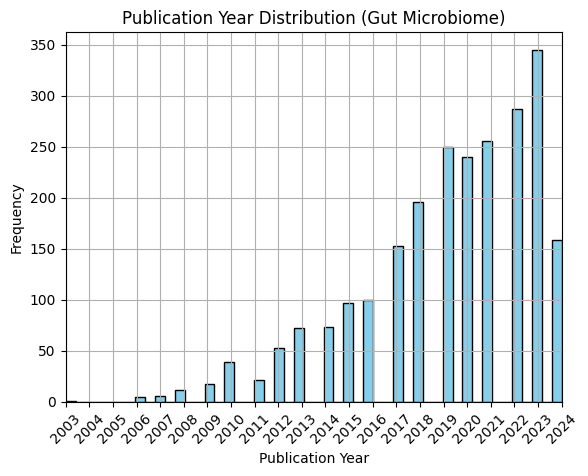

In [37]:
result_df_gm['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution (Gut Microbiome)')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df_gm['publication_year'].min(), result_df_gm['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(result_df_gm['publication_year'].min(),2024)

# Show the plot
plt.show()

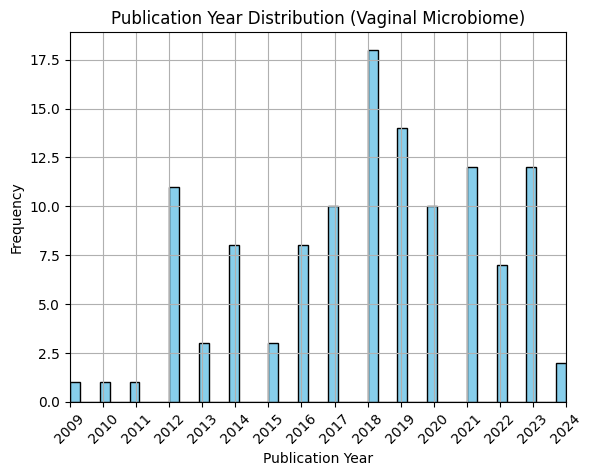

In [38]:
result_df_vm['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution (Vaginal Microbiome)')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df_vm['publication_year'].min(), result_df_vm['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(result_df_vm['publication_year'].min(),2024)

# Show the plot
plt.show()

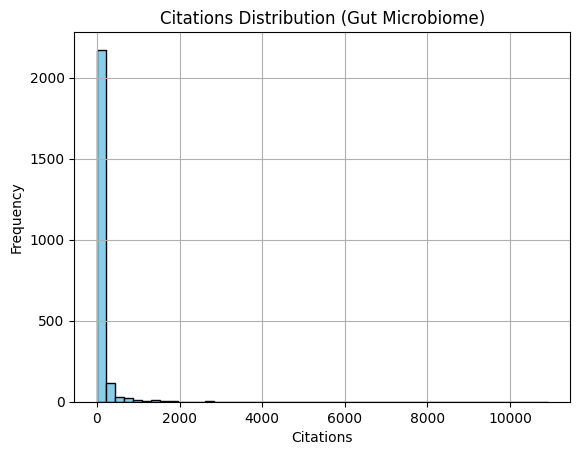

In [39]:
result_df_gm['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations Distribution (Gut Microbiome)')
plt.xlabel('Citations')
plt.ylabel('Frequency')

# Show the plot
plt.show()

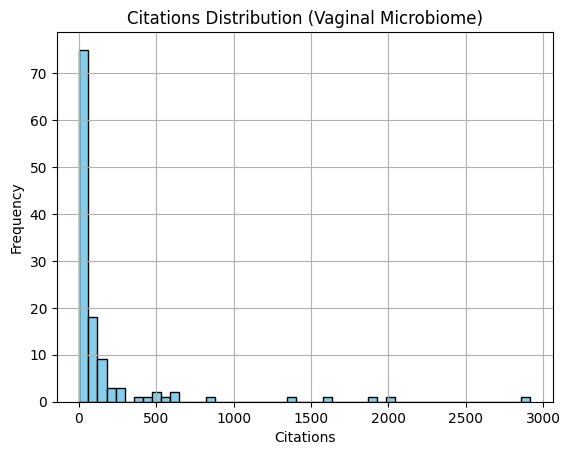

In [40]:
result_df_vm['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations Distribution (Vaginal Microbiome)')
plt.xlabel('Citations')
plt.ylabel('Frequency')

# Show the plot
plt.show()